<a href="https://colab.research.google.com/github/Wizako-01/Sensitivity-Optimized-Tuberculosis-Triage-Using-Nigerian-Chest-X-rays/blob/main/TB_sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
TRAIN_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/train_folder"
TEST_DIR  = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/test_folder"

In [2]:
import os

TRAIN_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/train_folder"
TEST_DIR  = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/test_folder"

print("Train folders:", os.listdir(TRAIN_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Train folders: ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']
Test folders: ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']


In [3]:
import os

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_images_by_class(folder):
    print(f"\nChecking: {folder}")
    total = 0

    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_ext)
            ])
            total += count
            print(f"{class_name}: {count}")

    print(f"Total: {total}")

count_images_by_class(TRAIN_DIR)
count_images_by_class(TEST_DIR)


Checking: /content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/train_folder
COVID: 500
NORMAL: 500
PNEUMONIA: 500
TB: 500
Total: 2000

Checking: /content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/test_folder
COVID: 150
NORMAL: 150
PNEUMONIA: 150
TB: 150
Total: 600


In [4]:
import os
import shutil
from pathlib import Path

# Original dataset paths
TRAIN_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/train_folder"
TEST_DIR  = "/content/drive/MyDrive/Nigeria_Xray_Project/my_dataset/test_folder"

# New binary dataset path
BINARY_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset"

# Class mapping
class_mapping = {
    "TB": "TB_positive",
    "COVID": "Non_TB",
    "NORMAL": "Non_TB",
    "PNEUMONIA": "Non_TB"
}

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def make_binary_dataset(source_dir, split_name):
    """
    Copies images from the original 4-class dataset into a new binary dataset:
    TB -> TB_positive
    COVID, NORMAL, PNEUMONIA -> Non_TB
    """

    for original_class, binary_class in class_mapping.items():
        source_class_dir = Path(source_dir) / original_class
        target_class_dir = Path(BINARY_DIR) / split_name / binary_class

        target_class_dir.mkdir(parents=True, exist_ok=True)

        if not source_class_dir.exists():
            print(f"Warning: {source_class_dir} does not exist")
            continue

        for img_file in source_class_dir.iterdir():
            if img_file.suffix.lower() in valid_ext:
                # Add original class name to avoid filename clashes inside Non_TB
                new_filename = f"{original_class}_{img_file.name}"
                target_path = target_class_dir / new_filename

                shutil.copy2(img_file, target_path)

# Create binary train and test datasets
make_binary_dataset(TRAIN_DIR, "train")
make_binary_dataset(TEST_DIR, "test")

print("Binary dataset created successfully!")
print("Saved at:", BINARY_DIR)

Binary dataset created successfully!
Saved at: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset


In [5]:
import os
from pathlib import Path

BINARY_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset"
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_binary_images(split):
    split_dir = Path(BINARY_DIR) / split
    print(f"\nChecking {split} set:")

    total = 0
    for class_name in sorted(os.listdir(split_dir)):
        class_path = split_dir / class_name

        if class_path.is_dir():
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_ext)
            ])
            total += count
            print(f"{class_name}: {count}")

    print(f"Total: {total}")

count_binary_images("train")
count_binary_images("test")


Checking train set:
Non_TB: 1500
TB_positive: 500
Total: 2000

Checking test set:
Non_TB: 450
TB_positive: 150
Total: 600


In [6]:
import os
import shutil
import random
from pathlib import Path

# Existing binary dataset
BINARY_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset")

# New dataset with train/val/test
SPLIT_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split")

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Reproducibility
random.seed(42)

def split_train_into_train_val(class_name, val_ratio=0.2):
    source_class_dir = BINARY_DIR / "train" / class_name

    train_target_dir = SPLIT_DIR / "train" / class_name
    val_target_dir = SPLIT_DIR / "val" / class_name

    train_target_dir.mkdir(parents=True, exist_ok=True)
    val_target_dir.mkdir(parents=True, exist_ok=True)

    images = [
        f for f in source_class_dir.iterdir()
        if f.suffix.lower() in valid_ext
    ]

    random.shuffle(images)

    val_count = int(len(images) * val_ratio)
    val_images = images[:val_count]
    train_images = images[val_count:]

    for img in train_images:
        shutil.copy2(img, train_target_dir / img.name)

    for img in val_images:
        shutil.copy2(img, val_target_dir / img.name)

    print(f"{class_name}: {len(train_images)} train, {len(val_images)} val")

# Split train into train and validation
for class_name in ["TB_positive", "Non_TB"]:
    split_train_into_train_val(class_name, val_ratio=0.2)

# Copy test set unchanged
for class_name in ["TB_positive", "Non_TB"]:
    source_test_dir = BINARY_DIR / "test" / class_name
    target_test_dir = SPLIT_DIR / "test" / class_name
    target_test_dir.mkdir(parents=True, exist_ok=True)

    for img in source_test_dir.iterdir():
        if img.suffix.lower() in valid_ext:
            shutil.copy2(img, target_test_dir / img.name)

print("\nTrain/validation/test split created successfully!")
print("Saved at:", SPLIT_DIR)

TB_positive: 400 train, 100 val
Non_TB: 1200 train, 300 val

Train/validation/test split created successfully!
Saved at: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split


In [7]:
from pathlib import Path
import os

SPLIT_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split")
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_split(split):
    print(f"\nChecking {split} set:")
    total = 0

    for class_name in sorted(os.listdir(SPLIT_DIR / split)):
        class_path = SPLIT_DIR / split / class_name

        if class_path.is_dir():
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_ext)
            ])
            total += count
            print(f"{class_name}: {count}")

    print(f"Total: {total}")

count_split("train")
count_split("val")
count_split("test")


Checking train set:
Non_TB: 1200
TB_positive: 400
Total: 1600

Checking val set:
Non_TB: 300
TB_positive: 100
Total: 400

Checking test set:
Non_TB: 450
TB_positive: 150
Total: 600


In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [9]:
DATA_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split"

TRAIN_DIR = f"{DATA_DIR}/train"
VAL_DIR   = f"{DATA_DIR}/val"
TEST_DIR  = f"{DATA_DIR}/test"

#NIGERIA ONLY BINARY MODEL

In [10]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# Dataset paths
# =========================
DATA_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)

Using device: cuda
GPU: Tesla T4
Train: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/train
Val: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/val
Test: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/test


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

print("Class mapping:", train_dataset.class_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Class mapping: {'Non_TB': 0, 'TB_positive': 1}
Train images: 1600
Validation images: 400
Test images: 600


In [13]:
# Class imbalance handling
class_counts = [0, 0]

for _, label in train_dataset.samples:
    class_counts[label] += 1

print("Class counts:", class_counts)

total_samples = sum(class_counts)
class_weights = [total_samples / count for count in class_counts]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class counts: [1200, 400]
Class weights: tensor([1.3333, 4.0000], device='cuda:0')


In [14]:
# Densenet-121

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Replace classifier for binary classification
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 88.9MB/s]


In [15]:
# training model

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)

            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_probs), np.array(all_preds)

In [16]:
EPOCHS = 15

best_model_wts = copy.deepcopy(model.state_dict())
best_val_auc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_probs, val_preds = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    val_auc = roc_auc_score(val_labels, val_probs)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        print("Best model updated.")

print("\nTraining complete.")
print("Best validation AUC:", best_val_auc)

model.load_state_dict(best_model_wts)


Epoch 1/15
------------------------------
Train Loss: 0.2197 | Train Acc: 0.8900
Val Loss:   0.0614 | Val Acc:   0.9875 | Val AUC: 0.9976
Best model updated.

Epoch 2/15
------------------------------
Train Loss: 0.0643 | Train Acc: 0.9825
Val Loss:   0.0309 | Val Acc:   0.9925 | Val AUC: 0.9991
Best model updated.

Epoch 3/15
------------------------------
Train Loss: 0.0308 | Train Acc: 0.9931
Val Loss:   0.0240 | Val Acc:   0.9950 | Val AUC: 0.9998
Best model updated.

Epoch 4/15
------------------------------
Train Loss: 0.0259 | Train Acc: 0.9956
Val Loss:   0.0206 | Val Acc:   0.9975 | Val AUC: 0.9995

Epoch 5/15
------------------------------
Train Loss: 0.0146 | Train Acc: 0.9969
Val Loss:   0.0140 | Val Acc:   0.9950 | Val AUC: 0.9999
Best model updated.

Epoch 6/15
------------------------------
Train Loss: 0.0088 | Train Acc: 0.9994
Val Loss:   0.0102 | Val Acc:   0.9975 | Val AUC: 1.0000
Best model updated.

Epoch 7/15
------------------------------
Train Loss: 0.0086 | Tr

<All keys matched successfully>

In [18]:
SAVE_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/densenet121_nigerian_only_tb_binary.pth"

torch.save(model.state_dict(), SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/Nigeria_Xray_Project/densenet121_nigerian_only_tb_binary.pth


In [19]:
# Evaluate best model

test_loss, test_acc, y_true, y_probs, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.023626851849257946
Test Accuracy: 0.9933333333333333


In [20]:
# clinical metrics evaluation

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
false_negative_rate = fn / (tp + fn)
false_positive_rate = fp / (fp + tn)
precision = tp / (tp + fp)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_probs)
auprc = average_precision_score(y_true, y_probs)
accuracy = accuracy_score(y_true, y_pred)

print("\nClinical Performance Metrics")
print("============================")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Sensitivity / Recall: {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"False Negative Rate:  {false_negative_rate:.4f}")
print(f"False Positive Rate:  {false_positive_rate:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"AUROC:                {auc:.4f}")
print(f"AUPRC:                {auprc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non_TB", "TB_positive"]
))

Confusion Matrix:
[[450   0]
 [  4 146]]

Clinical Performance Metrics
Accuracy:             0.9933
Sensitivity / Recall: 0.9733
Specificity:          1.0000
False Negative Rate:  0.0267
False Positive Rate:  0.0000
Precision:            1.0000
F1-score:             0.9865
AUROC:                0.9995
AUPRC:                0.9988

Classification Report:
              precision    recall  f1-score   support

      Non_TB       0.99      1.00      1.00       450
 TB_positive       1.00      0.97      0.99       150

    accuracy                           0.99       600
   macro avg       1.00      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



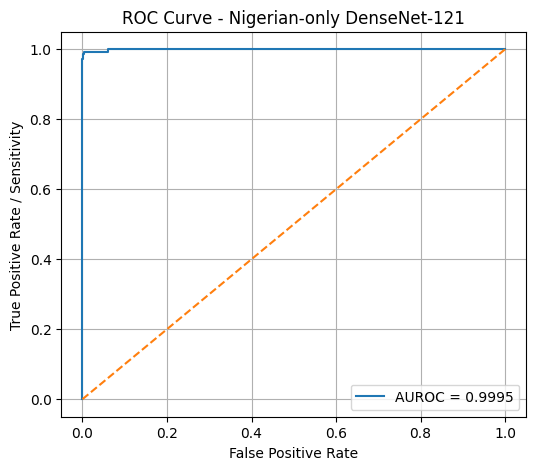

In [21]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curve - Nigerian-only DenseNet-121")
plt.legend()
plt.grid(True)
plt.show()

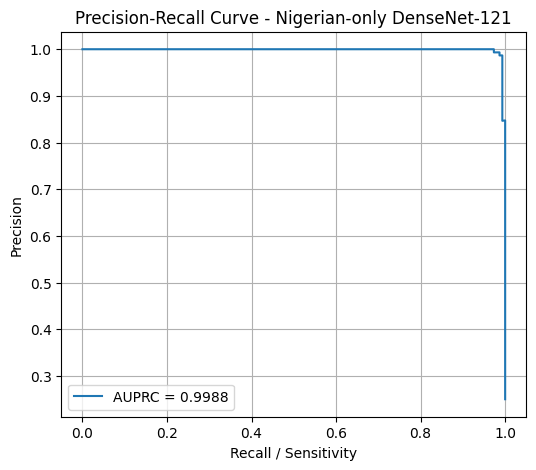

In [22]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Nigerian-only DenseNet-121")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
def sensitivity_at_fixed_specificity(y_true, y_probs, target_specificity=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    specificity = 1 - fpr

    valid_indices = np.where(specificity >= target_specificity)[0]

    if len(valid_indices) == 0:
        return None, None, None

    best_index = valid_indices[np.argmax(tpr[valid_indices])]

    return tpr[best_index], specificity[best_index], thresholds[best_index]


for spec in [0.80, 0.85, 0.90, 0.95]:
    sens, actual_spec, threshold = sensitivity_at_fixed_specificity(
        y_true,
        y_probs,
        target_specificity=spec
    )

    if sens is not None:
        print(f"At specificity ≥ {spec:.2f}:")
        print(f"  Sensitivity = {sens:.4f}")
        print(f"  Specificity = {actual_spec:.4f}")
        print(f"  Threshold   = {threshold:.4f}")
    else:
        print(f"No threshold found for specificity ≥ {spec:.2f}")

At specificity ≥ 0.80:
  Sensitivity = 1.0000
  Specificity = 0.9400
  Threshold   = 0.0049
At specificity ≥ 0.85:
  Sensitivity = 1.0000
  Specificity = 0.9400
  Threshold   = 0.0049
At specificity ≥ 0.90:
  Sensitivity = 1.0000
  Specificity = 0.9400
  Threshold   = 0.0049
At specificity ≥ 0.95:
  Sensitivity = 0.9933
  Specificity = 0.9956
  Threshold   = 0.1744


In [24]:
# save evaluation metrics
import pandas as pd

results_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "tb_probability": y_probs
})

results_df["true_class"] = results_df["true_label"].map({0: "Non_TB", 1: "TB_positive"})
results_df["predicted_class"] = results_df["predicted_label"].map({0: "Non_TB", 1: "TB_positive"})

CSV_SAVE_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/nigerian_only_test_predictions.csv"

results_df.to_csv(CSV_SAVE_PATH, index=False)

print("Predictions saved to:", CSV_SAVE_PATH)
results_df.head()

Predictions saved to: /content/drive/MyDrive/Nigeria_Xray_Project/nigerian_only_test_predictions.csv


,true_label,predicted_label,tb_probability,true_class,predicted_class
0,0,0,0.000100,Non_TB,Non_TB
1,0,0,0.002037,Non_TB,Non_TB
2,0,0,0.000285,Non_TB,Non_TB
3,0,0,0.000106,Non_TB,Non_TB
4,0,0,0.204331,Non_TB,Non_TB


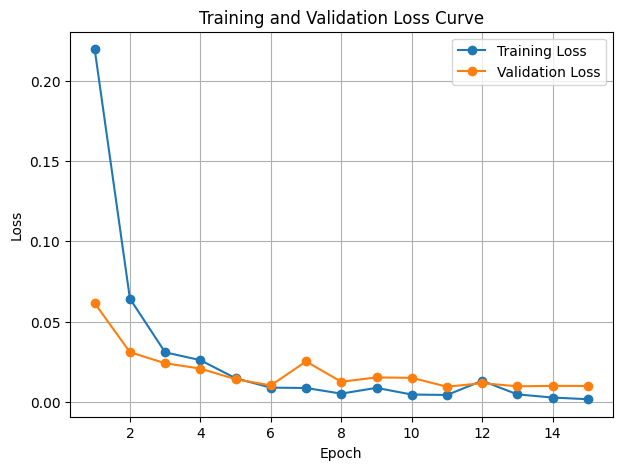

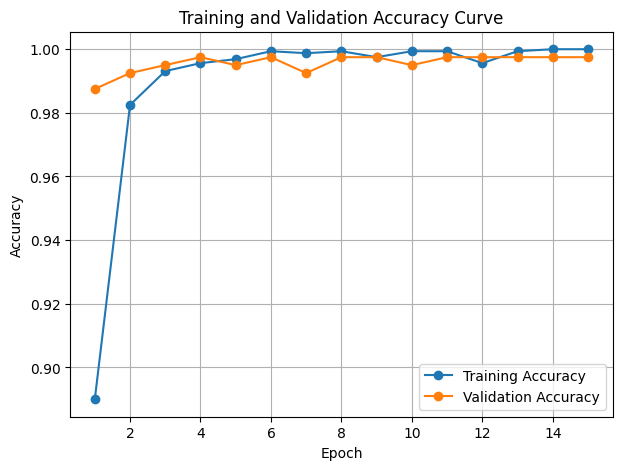

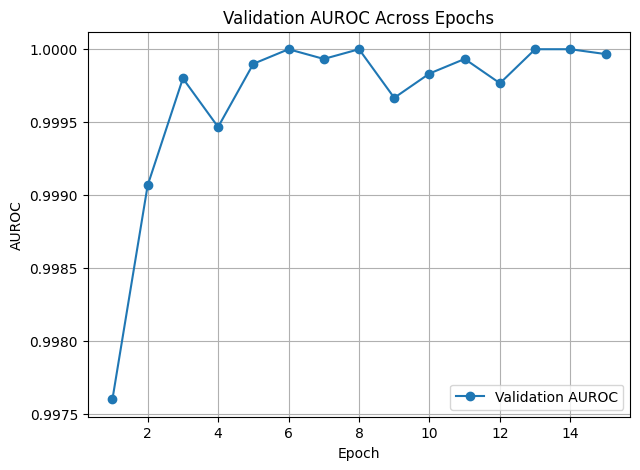

In [25]:
# graphical representation
# =========================
# Training and validation curves
# =========================

epochs_range = range(1, len(history["train_loss"]) + 1)

# 1. Loss curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# 2. Accuracy curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

# 3. Validation AUROC curve across epochs
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["val_auc"], marker="o", label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Validation AUROC Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Identify false-negative TB cases
# False negative = true TB_positive but predicted Non_TB

false_negatives = results_df[
    (results_df["true_class"] == "TB_positive") &
    (results_df["predicted_class"] == "Non_TB")
]

print("Number of false-negative TB cases:", len(false_negatives))
false_negatives

Number of false-negative TB cases: 4


,true_label,predicted_label,tb_probability,true_class,predicted_class
477,1,0,0.004880,TB_positive,Non_TB
496,1,0,0.215341,TB_positive,Non_TB
567,1,0,0.335682,TB_positive,Non_TB
599,1,0,0.174391,TB_positive,Non_TB


# MODEL trained on external dataset only


In [1]:
import os

drive_root = "/content/drive/MyDrive"

zip_files = []

for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_files.append(os.path.join(root, file))

print("ZIP files found:")
for z in zip_files:
    print(z)

ZIP files found:
/content/drive/MyDrive/Normal-20260516T084217Z-3-001.zip
/content/drive/MyDrive/Tuberculosis-20260516T084219Z-3-001.zip


In [2]:
import zipfile
from pathlib import Path
import os

# ZIP paths
NORMAL_ZIP = "/content/drive/MyDrive/Normal-20260516T084217Z-3-001.zip"
TB_ZIP = "/content/drive/MyDrive/Tuberculosis-20260516T084219Z-3-001.zip"

# Destination folder
EXTERNAL_RAW_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw")

NORMAL_EXTRACT_DIR = EXTERNAL_RAW_DIR / "Normal"
TB_EXTRACT_DIR = EXTERNAL_RAW_DIR / "Tuberculosis"

NORMAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
TB_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Unzip Normal
with zipfile.ZipFile(NORMAL_ZIP, "r") as zip_ref:
    zip_ref.extractall(NORMAL_EXTRACT_DIR)

# Unzip Tuberculosis
with zipfile.ZipFile(TB_ZIP, "r") as zip_ref:
    zip_ref.extractall(TB_EXTRACT_DIR)

print("Unzipping complete.")
print("Normal extracted to:", NORMAL_EXTRACT_DIR)
print("Tuberculosis extracted to:", TB_EXTRACT_DIR)

Unzipping complete.
Normal extracted to: /content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw/Normal
Tuberculosis extracted to: /content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw/Tuberculosis


In [3]:
import os
from pathlib import Path

EXTERNAL_RAW_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw")

for root, dirs, files in os.walk(EXTERNAL_RAW_DIR):
    level = root.replace(str(EXTERNAL_RAW_DIR), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for file in files[:5]:
        print(f"{subindent}{file}")

external_tb_raw/
    Normal/
        Normal/
            Normal-898.png
            Normal-883.png
            Normal-865.png
            Normal-964.png
            Normal-95.png
    Tuberculosis/
        Tuberculosis/
            Tuberculosis-650.png
            Tuberculosis-630.png
            Tuberculosis-64.png
            Tuberculosis-633.png
            Tuberculosis-57.png


In [4]:
from pathlib import Path
import os

EXTERNAL_RAW_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw")
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_all_images(folder):
    count = 0
    for path in Path(folder).rglob("*"):
        if path.suffix.lower() in valid_ext:
            count += 1
    return count

normal_count = count_all_images(EXTERNAL_RAW_DIR / "Normal")
tb_count = count_all_images(EXTERNAL_RAW_DIR / "Tuberculosis")

print("External Normal images:", normal_count)
print("External Tuberculosis images:", tb_count)
print("Total external images:", normal_count + tb_count)

External Normal images: 3500
External Tuberculosis images: 700
Total external images: 4200


In [5]:
import os
import shutil
import random
from pathlib import Path

# Raw external dataset location
EXTERNAL_RAW_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_raw")

# New organized folder for external pretraining
EXTERNAL_SPLIT_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split")

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Reproducibility
random.seed(42)

# Class folders
classes = {
    "Normal": EXTERNAL_RAW_DIR / "Normal",
    "Tuberculosis": EXTERNAL_RAW_DIR / "Tuberculosis"
}

def get_all_images(folder):
    """Find all image files inside a class folder, including subfolders."""
    return [
        path for path in Path(folder).rglob("*")
        if path.suffix.lower() in valid_ext
    ]

def split_and_copy_class(class_name, source_folder):
    """Split one class into train/val/test and copy images."""

    images = get_all_images(source_folder)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    split_files = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in split_files.items():
        target_dir = EXTERNAL_SPLIT_DIR / split / class_name
        target_dir.mkdir(parents=True, exist_ok=True)

        for img_path in files:
            # Add class name to prevent filename clashes
            new_name = f"{class_name}_{img_path.name}"
            shutil.copy2(img_path, target_dir / new_name)

    print(f"{class_name}:")
    print(f"  Train: {len(split_files['train'])}")
    print(f"  Val:   {len(split_files['val'])}")
    print(f"  Test:  {len(split_files['test'])}")

# Create splits for both classes
for class_name, source_folder in classes.items():
    split_and_copy_class(class_name, source_folder)

print("\nExternal pretraining dataset created at:")
print(EXTERNAL_SPLIT_DIR)

Normal:
  Train: 2450
  Val:   525
  Test:  525
Tuberculosis:
  Train: 489
  Val:   106
  Test:  105

External pretraining dataset created at:
/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split


In [6]:
from pathlib import Path
import os

EXTERNAL_SPLIT_DIR = Path("/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split")
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def count_split_images(split):
    print(f"\nChecking {split} set:")
    total = 0

    for class_name in sorted(os.listdir(EXTERNAL_SPLIT_DIR / split)):
        class_path = EXTERNAL_SPLIT_DIR / split / class_name

        if class_path.is_dir():
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_ext)
            ])
            total += count
            print(f"{class_name}: {count}")

    print(f"Total: {total}")

count_split_images("train")
count_split_images("val")
count_split_images("test")


Checking train set:
Normal: 2450
Tuberculosis: 489
Total: 2939

Checking val set:
Normal: 525
Tuberculosis: 106
Total: 631

Checking test set:
Normal: 525
Tuberculosis: 105
Total: 630


In [7]:
# Imports, paths, and device
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    roc_curve,
    precision_recall_curve
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# External pretraining dataset paths
EXTERNAL_DATA_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split"

EXT_TRAIN_DIR = os.path.join(EXTERNAL_DATA_DIR, "train")
EXT_VAL_DIR   = os.path.join(EXTERNAL_DATA_DIR, "val")
EXT_TEST_DIR  = os.path.join(EXTERNAL_DATA_DIR, "test")

print("External train:", EXT_TRAIN_DIR)
print("External val:", EXT_VAL_DIR)
print("External test:", EXT_TEST_DIR)

Using device: cuda
GPU: Tesla T4
External train: /content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split/train
External val: /content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split/val
External test: /content/drive/MyDrive/Nigeria_Xray_Project/external_tb_pretraining_split/test


In [8]:
#image transformation

IMG_SIZE = 224
BATCH_SIZE = 32

# Augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# No augmentation for validation and test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
#Load external dataset
ext_train_dataset = datasets.ImageFolder(EXT_TRAIN_DIR, transform=train_transforms)
ext_val_dataset   = datasets.ImageFolder(EXT_VAL_DIR, transform=val_test_transforms)
ext_test_dataset  = datasets.ImageFolder(EXT_TEST_DIR, transform=val_test_transforms)

print("Class mapping:", ext_train_dataset.class_to_idx)

ext_train_loader = DataLoader(
    ext_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

ext_val_loader = DataLoader(
    ext_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

ext_test_loader = DataLoader(
    ext_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train images:", len(ext_train_dataset))
print("Validation images:", len(ext_val_dataset))
print("Test images:", len(ext_test_dataset))

Class mapping: {'Normal': 0, 'Tuberculosis': 1}
Train images: 2939
Validation images: 631
Test images: 630


In [10]:
#Class weighting
class_counts = [0, 0]

for _, label in ext_train_dataset.samples:
    class_counts[label] += 1

print("Class counts:", class_counts)

total_samples = sum(class_counts)
class_weights = [total_samples / count for count in class_counts]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class counts: [2450, 489]
Class weights: tensor([1.1996, 6.0102], device='cuda:0')


In [11]:
#Build DenseNet-121 for external pretraining
model_ext = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Replace final classifier for 2 classes: Normal and Tuberculosis
num_features = model_ext.classifier.in_features
model_ext.classifier = nn.Linear(num_features, 2)

model_ext = model_ext.to(device)

optimizer = optim.AdamW(model_ext.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [12]:
# Training and evaluation functions
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_probs), np.array(all_preds)

In [13]:
# Train on external TB/Normal dataset
EPOCHS = 10

best_model_wts = copy.deepcopy(model_ext.state_dict())
best_val_auc = 0.0

history_ext = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    train_loss, train_acc = train_one_epoch(
        model_ext,
        ext_train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_probs, val_preds = evaluate(
        model_ext,
        ext_val_loader,
        criterion,
        device
    )

    val_auc = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history_ext["train_loss"].append(train_loss)
    history_ext["train_acc"].append(train_acc)
    history_ext["val_loss"].append(val_loss)
    history_ext["val_acc"].append(val_acc)
    history_ext["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_wts = copy.deepcopy(model_ext.state_dict())
        print("Best external pretrained model updated.")

print("\nExternal pretraining complete.")
print("Best validation AUC:", best_val_auc)

model_ext.load_state_dict(best_model_wts)


Epoch 1/10
------------------------------
Train Loss: 0.1499 | Train Acc: 0.9241
Val Loss:   0.0185 | Val Acc:   0.9968 | Val AUC: 0.9997
Best external pretrained model updated.

Epoch 2/10
------------------------------
Train Loss: 0.0392 | Train Acc: 0.9898
Val Loss:   0.0204 | Val Acc:   0.9968 | Val AUC: 0.9999
Best external pretrained model updated.

Epoch 3/10
------------------------------
Train Loss: 0.0194 | Train Acc: 0.9959
Val Loss:   0.0085 | Val Acc:   0.9984 | Val AUC: 1.0000
Best external pretrained model updated.

Epoch 4/10
------------------------------
Train Loss: 0.0179 | Train Acc: 0.9973
Val Loss:   0.0075 | Val Acc:   0.9984 | Val AUC: 1.0000

Epoch 5/10
------------------------------
Train Loss: 0.0075 | Train Acc: 0.9980
Val Loss:   0.0095 | Val Acc:   0.9984 | Val AUC: 0.9998

Epoch 6/10
------------------------------
Train Loss: 0.0170 | Train Acc: 0.9963
Val Loss:   0.0083 | Val Acc:   0.9984 | Val AUC: 0.9999

Epoch 7/10
------------------------------
Tra

<All keys matched successfully>

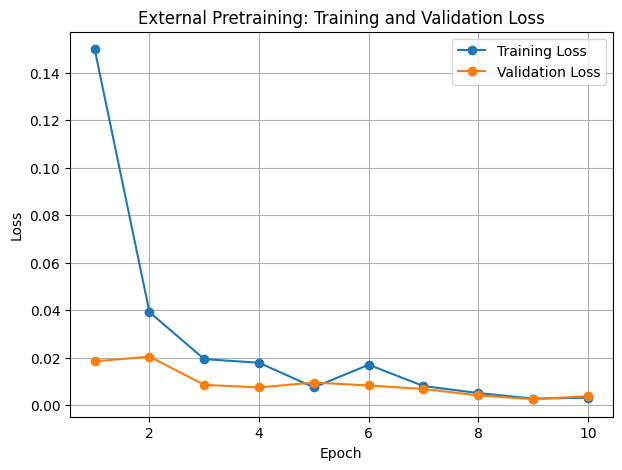

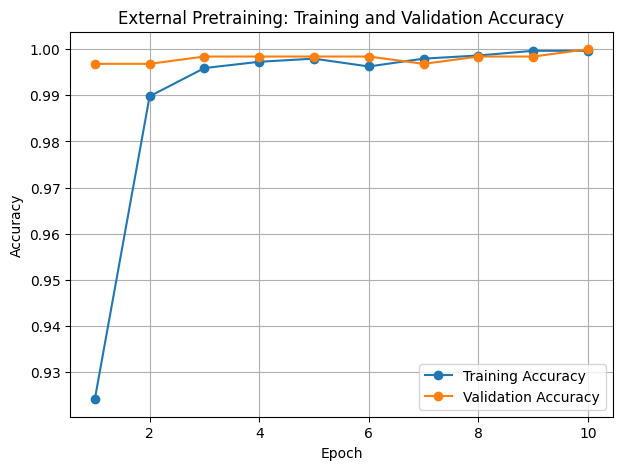

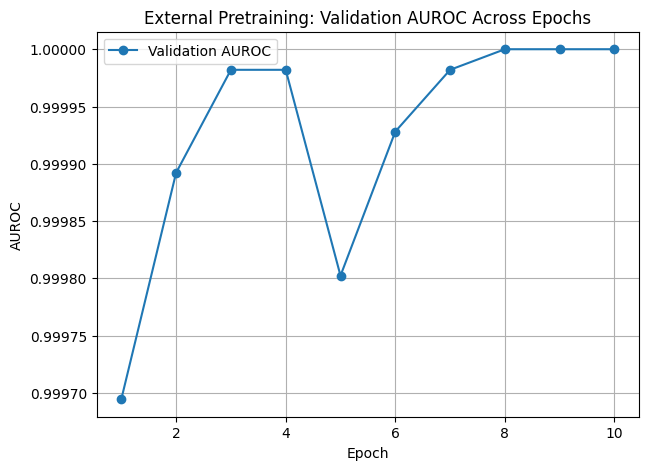

In [14]:
#Plot external pretraining curves
epochs_range = range(1, len(history_ext["train_loss"]) + 1)

# Loss curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ext["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history_ext["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("External Pretraining: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ext["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history_ext["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("External Pretraining: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Validation AUROC curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ext["val_auc"], marker="o", label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("External Pretraining: Validation AUROC Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
EXT_SAVE_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_tb_pretrained.pth"

torch.save(model_ext.state_dict(), EXT_SAVE_PATH)

print("External pretrained model saved to:", EXT_SAVE_PATH)

External pretrained model saved to: /content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_tb_pretrained.pth


In [16]:
ext_test_loss, ext_test_acc, ext_y_true, ext_y_probs, ext_y_pred = evaluate(
    model_ext,
    ext_test_loader,
    criterion,
    device
)

print("External Test Loss:", ext_test_loss)
print("External Test Accuracy:", ext_test_acc)

External Test Loss: 0.007061333139796578
External Test Accuracy: 0.9968253968253968


In [17]:
cm = confusion_matrix(ext_y_true, ext_y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
false_negative_rate = fn / (tp + fn)
false_positive_rate = fp / (fp + tn)
precision = tp / (tp + fp)
f1 = f1_score(ext_y_true, ext_y_pred)
auc = roc_auc_score(ext_y_true, ext_y_probs)
auprc = average_precision_score(ext_y_true, ext_y_probs)
accuracy = accuracy_score(ext_y_true, ext_y_pred)

print("\nExternal Pretraining Test Metrics")
print("=================================")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Sensitivity / Recall: {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"False Negative Rate:  {false_negative_rate:.4f}")
print(f"False Positive Rate:  {false_positive_rate:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"AUROC:                {auc:.4f}")
print(f"AUPRC:                {auprc:.4f}")

print("\nClassification Report:")
print(classification_report(
    ext_y_true,
    ext_y_pred,
    target_names=["Normal", "Tuberculosis"]
))

Confusion Matrix:
[[525   0]
 [  2 103]]

External Pretraining Test Metrics
Accuracy:             0.9968
Sensitivity / Recall: 0.9810
Specificity:          1.0000
False Negative Rate:  0.0190
False Positive Rate:  0.0000
Precision:            1.0000
F1-score:             0.9904
AUROC:                1.0000
AUPRC:                1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       525
Tuberculosis       1.00      0.98      0.99       105

    accuracy                           1.00       630
   macro avg       1.00      0.99      0.99       630
weighted avg       1.00      1.00      1.00       630



# External Model fine-tuned on local data set

In [18]:
#Load libraries, paths, and device
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Nigerian binary dataset
NIGERIAN_DATA_DIR = "/content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split"

NIG_TRAIN_DIR = os.path.join(NIGERIAN_DATA_DIR, "train")
NIG_VAL_DIR   = os.path.join(NIGERIAN_DATA_DIR, "val")
NIG_TEST_DIR  = os.path.join(NIGERIAN_DATA_DIR, "test")

# Saved external pretrained model
EXT_PRETRAINED_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_tb_pretrained.pth"

print("Nigerian train:", NIG_TRAIN_DIR)
print("Nigerian val:", NIG_VAL_DIR)
print("Nigerian test:", NIG_TEST_DIR)
print("External pretrained model:", EXT_PRETRAINED_PATH)

Using device: cuda
GPU: Tesla T4
Nigerian train: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/train
Nigerian val: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/val
Nigerian test: /content/drive/MyDrive/Nigeria_Xray_Project/binary_dataset_split/test
External pretrained model: /content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_tb_pretrained.pth


In [20]:
#Image transformations
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
#Load Nigerian binary dataset
nig_train_dataset = datasets.ImageFolder(NIG_TRAIN_DIR, transform=train_transforms)
nig_val_dataset   = datasets.ImageFolder(NIG_VAL_DIR, transform=val_test_transforms)
nig_test_dataset  = datasets.ImageFolder(NIG_TEST_DIR, transform=val_test_transforms)

print("Class mapping:", nig_train_dataset.class_to_idx)

nig_train_loader = DataLoader(
    nig_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

nig_val_loader = DataLoader(
    nig_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

nig_test_loader = DataLoader(
    nig_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train images:", len(nig_train_dataset))
print("Validation images:", len(nig_val_dataset))
print("Test images:", len(nig_test_dataset))

Class mapping: {'Non_TB': 0, 'TB_positive': 1}
Train images: 1600
Validation images: 400
Test images: 600


In [22]:
# Class weighting for Nigerian dataset
class_counts = [0, 0]

for _, label in nig_train_dataset.samples:
    class_counts[label] += 1

print("Class counts:", class_counts)

total_samples = sum(class_counts)
class_weights = [total_samples / count for count in class_counts]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class counts: [1200, 400]
Class weights: tensor([1.3333, 4.0000], device='cuda:0')


In [23]:
# Load the external pretrained DenseNet-121
# Build DenseNet-121 with 2-class classifier
model_ft = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

num_features = model_ft.classifier.in_features
model_ft.classifier = nn.Linear(num_features, 2)

# Load the external TB/Normal pretrained weights
model_ft.load_state_dict(torch.load(EXT_PRETRAINED_PATH, map_location=device))

model_ft = model_ft.to(device)

print("External pretrained weights loaded successfully.")

External pretrained weights loaded successfully.


In [24]:
#Optimizer and scheduler
optimizer = optim.AdamW(model_ft.parameters(), lr=5e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [25]:
#Training and evaluation functions
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_probs), np.array(all_preds)

In [26]:
#Fine-tune on Nigerian dataset
EPOCHS = 15

best_model_wts = copy.deepcopy(model_ft.state_dict())
best_val_auc = 0.0

history_ft = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    train_loss, train_acc = train_one_epoch(
        model_ft,
        nig_train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_probs, val_preds = evaluate(
        model_ft,
        nig_val_loader,
        criterion,
        device
    )

    val_auc = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history_ft["train_loss"].append(train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_acc"].append(val_acc)
    history_ft["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_wts = copy.deepcopy(model_ft.state_dict())
        print("Best fine-tuned model updated.")

print("\nFine-tuning complete.")
print("Best validation AUC:", best_val_auc)

model_ft.load_state_dict(best_model_wts)


Epoch 1/15
------------------------------
Train Loss: 0.0772 | Train Acc: 0.9750
Val Loss:   0.0070 | Val Acc:   0.9975 | Val AUC: 1.0000
Best fine-tuned model updated.

Epoch 2/15
------------------------------
Train Loss: 0.0148 | Train Acc: 0.9962
Val Loss:   0.0054 | Val Acc:   1.0000 | Val AUC: 1.0000

Epoch 3/15
------------------------------
Train Loss: 0.0121 | Train Acc: 0.9969
Val Loss:   0.0024 | Val Acc:   1.0000 | Val AUC: 1.0000

Epoch 4/15
------------------------------
Train Loss: 0.0135 | Train Acc: 0.9969
Val Loss:   0.0020 | Val Acc:   1.0000 | Val AUC: 1.0000

Epoch 5/15
------------------------------
Train Loss: 0.0039 | Train Acc: 1.0000
Val Loss:   0.0042 | Val Acc:   0.9975 | Val AUC: 1.0000

Epoch 6/15
------------------------------
Train Loss: 0.0029 | Train Acc: 0.9994
Val Loss:   0.0018 | Val Acc:   1.0000 | Val AUC: 1.0000

Epoch 7/15
------------------------------
Train Loss: 0.0038 | Train Acc: 0.9988
Val Loss:   0.0028 | Val Acc:   1.0000 | Val AUC: 1.0

<All keys matched successfully>

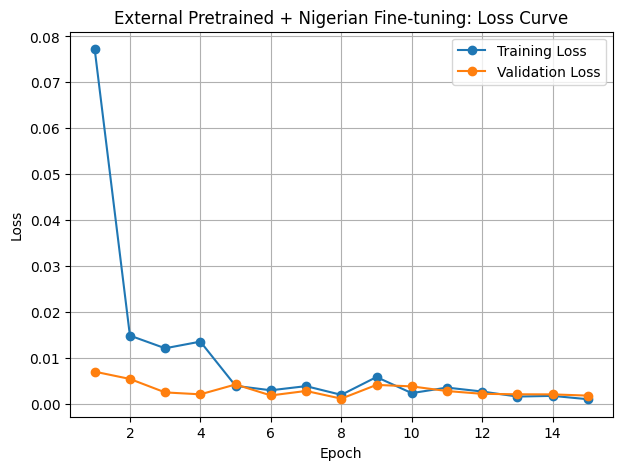

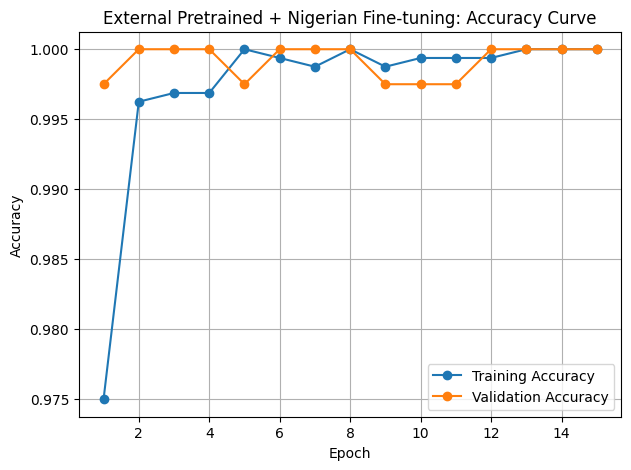

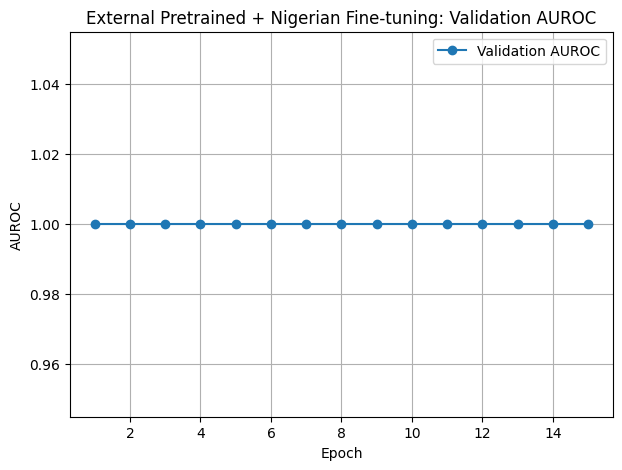

In [27]:
#Plot fine-tuning curves
epochs_range = range(1, len(history_ft["train_loss"]) + 1)

# Loss curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ft["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history_ft["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("External Pretrained + Nigerian Fine-tuning: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ft["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history_ft["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("External Pretrained + Nigerian Fine-tuning: Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

# Validation AUROC curve
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_ft["val_auc"], marker="o", label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("External Pretrained + Nigerian Fine-tuning: Validation AUROC")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#Save the fine-tuned model
FT_SAVE_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_pretrained_nigerian_finetuned.pth"

torch.save(model_ft.state_dict(), FT_SAVE_PATH)

print("Fine-tuned model saved to:", FT_SAVE_PATH)

Fine-tuned model saved to: /content/drive/MyDrive/Nigeria_Xray_Project/densenet121_external_pretrained_nigerian_finetuned.pth


In [29]:
#Evaluate on Nigerian test set
test_loss, test_acc, y_true_ft, y_probs_ft, y_pred_ft = evaluate(
    model_ft,
    nig_test_loader,
    criterion,
    device
)

print("Nigerian Test Loss:", test_loss)
print("Nigerian Test Accuracy:", test_acc)

Nigerian Test Loss: 0.021217391546815633
Nigerian Test Accuracy: 0.995


In [30]:
#Clinical metrics on Nigerian test set
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
print("Confusion Matrix:")
print(cm_ft)

tn, fp, fn, tp = cm_ft.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
false_negative_rate = fn / (tp + fn)
false_positive_rate = fp / (fp + tn)
precision = tp / (tp + fp)
f1 = f1_score(y_true_ft, y_pred_ft)
auc = roc_auc_score(y_true_ft, y_probs_ft)
auprc = average_precision_score(y_true_ft, y_probs_ft)
accuracy = accuracy_score(y_true_ft, y_pred_ft)

print("\nExternal Pretrained + Nigerian Fine-tuned Test Metrics")
print("======================================================")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Sensitivity / Recall: {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"False Negative Rate:  {false_negative_rate:.4f}")
print(f"False Positive Rate:  {false_positive_rate:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"AUROC:                {auc:.4f}")
print(f"AUPRC:                {auprc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=["Non_TB", "TB_positive"]
))

Confusion Matrix:
[[448   2]
 [  1 149]]

External Pretrained + Nigerian Fine-tuned Test Metrics
Accuracy:             0.9950
Sensitivity / Recall: 0.9933
Specificity:          0.9956
False Negative Rate:  0.0067
False Positive Rate:  0.0044
Precision:            0.9868
F1-score:             0.9900
AUROC:                0.9995
AUPRC:                0.9984

Classification Report:
              precision    recall  f1-score   support

      Non_TB       1.00      1.00      1.00       450
 TB_positive       0.99      0.99      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       1.00      0.99      1.00       600



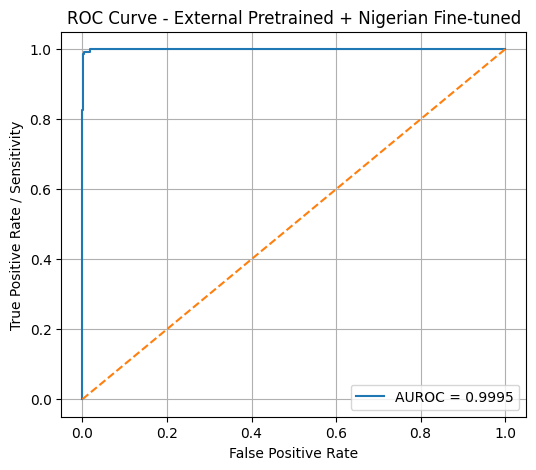

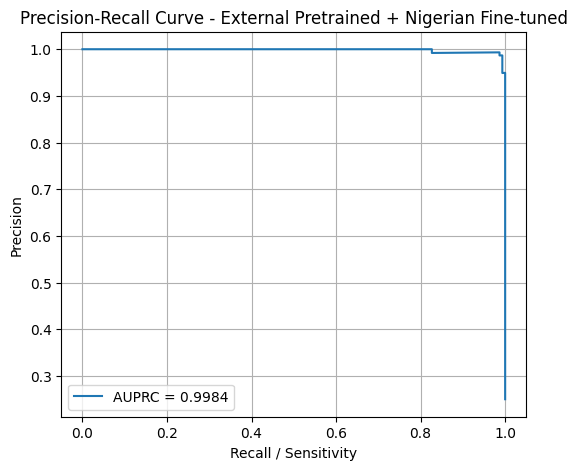

In [31]:
#Plot ROC and Precision-Recall curves
# ROC curve
fpr, tpr, thresholds = roc_curve(y_true_ft, y_probs_ft)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curve - External Pretrained + Nigerian Fine-tuned")
plt.legend()
plt.grid(True)
plt.show()

# Precision-recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true_ft, y_probs_ft)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - External Pretrained + Nigerian Fine-tuned")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
#Sensitivity at fixed specificity thresholds
def sensitivity_at_fixed_specificity(y_true, y_probs, target_specificity=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    specificity = 1 - fpr

    valid_indices = np.where(specificity >= target_specificity)[0]

    if len(valid_indices) == 0:
        return None, None, None

    best_index = valid_indices[np.argmax(tpr[valid_indices])]

    return tpr[best_index], specificity[best_index], thresholds[best_index]


for spec in [0.80, 0.85, 0.90, 0.95]:
    sens, actual_spec, threshold = sensitivity_at_fixed_specificity(
        y_true_ft,
        y_probs_ft,
        target_specificity=spec
    )

    if sens is not None:
        print(f"At specificity ≥ {spec:.2f}:")
        print(f"  Sensitivity = {sens:.4f}")
        print(f"  Specificity = {actual_spec:.4f}")
        print(f"  Threshold   = {threshold:.4f}")
    else:
        print(f"No threshold found for specificity ≥ {spec:.2f}")

At specificity ≥ 0.80:
  Sensitivity = 1.0000
  Specificity = 0.9822
  Threshold   = 0.1866
At specificity ≥ 0.85:
  Sensitivity = 1.0000
  Specificity = 0.9822
  Threshold   = 0.1866
At specificity ≥ 0.90:
  Sensitivity = 1.0000
  Specificity = 0.9822
  Threshold   = 0.1866
At specificity ≥ 0.95:
  Sensitivity = 1.0000
  Specificity = 0.9822
  Threshold   = 0.1866


In [33]:
#Save fine-tuned test predictions
# File paths from Nigerian test dataset
test_file_paths = [path for path, label in nig_test_dataset.samples]

results_ft_df = pd.DataFrame({
    "file_path": test_file_paths,
    "true_label": y_true_ft,
    "predicted_label": y_pred_ft,
    "tb_probability": y_probs_ft
})

results_ft_df["true_class"] = results_ft_df["true_label"].map({0: "Non_TB", 1: "TB_positive"})
results_ft_df["predicted_class"] = results_ft_df["predicted_label"].map({0: "Non_TB", 1: "TB_positive"})

CSV_SAVE_PATH = "/content/drive/MyDrive/Nigeria_Xray_Project/external_pretrained_nigerian_finetuned_test_predictions.csv"

results_ft_df.to_csv(CSV_SAVE_PATH, index=False)

print("Predictions saved to:", CSV_SAVE_PATH)
results_ft_df.head()

Predictions saved to: /content/drive/MyDrive/Nigeria_Xray_Project/external_pretrained_nigerian_finetuned_test_predictions.csv


,file_path,true_label,predicted_label,tb_probability,true_class,predicted_class
0,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,0,0,0.000004,Non_TB,Non_TB
1,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,0,0,0.000155,Non_TB,Non_TB
2,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,0,0,0.000917,Non_TB,Non_TB
3,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,0,0,0.000216,Non_TB,Non_TB
4,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,0,0,0.000165,Non_TB,Non_TB


In [34]:
#False-negative analysis
false_negatives_ft = results_ft_df[
    (results_ft_df["true_class"] == "TB_positive") &
    (results_ft_df["predicted_class"] == "Non_TB")
]

print("Number of false-negative TB cases:", len(false_negatives_ft))
false_negatives_ft[["file_path", "true_class", "predicted_class", "tb_probability"]]

Number of false-negative TB cases: 1


,file_path,true_class,predicted_class,tb_probability
567,/content/drive/MyDrive/Nigeria_Xray_Project/bi...,TB_positive,Non_TB,0.186593
